In [1]:
#!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement du dataset prêt pour le Machine Learning
chemin_fichier = '../data/application_train_cleaned.csv'
df = pd.read_csv(chemin_fichier)

print(f"Taille du dataset : {df.shape}")

Taille du dataset : (307511, 216)


In [3]:
y = df['TARGET']
X = df.drop(columns=["TARGET"])

# Séparation des données (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Tailles des splits
print(f"Taille de X_train : {X_train.shape}")
print(f"Taille de X_test  : {X_test.shape}")

Taille de X_train : (246008, 215)
Taille de X_test  : (61503, 215)


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:

modele_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

modele_lr.fit(X_train_scaled, y_train)

y_pred = modele_lr.predict(X_test_scaled)


=== Matrice de Confusion ===


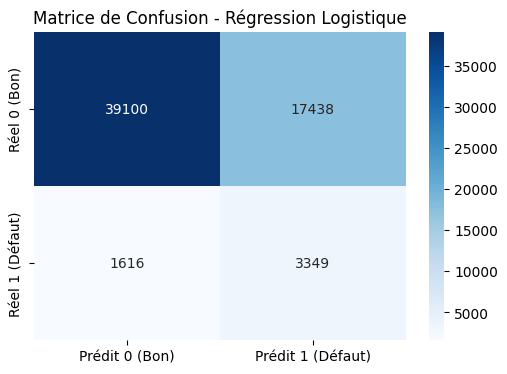


=== Rapport de Classification ===
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [6]:
# 1. Matrice de confusion visuelle
print("=== Matrice de Confusion ===")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
# On utilise Seaborn pour faire une belle carte de chaleur (heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Prédit 0 (Bon)', 'Prédit 1 (Défaut)'], 
            yticklabels=['Réel 0 (Bon)', 'Réel 1 (Défaut)'])
plt.title('Matrice de Confusion - Régression Logistique')
plt.show()

# 2. Rapport de classification (Les métriques détaillées)
print("\n=== Rapport de Classification ===")
print(classification_report(y_test, y_pred))

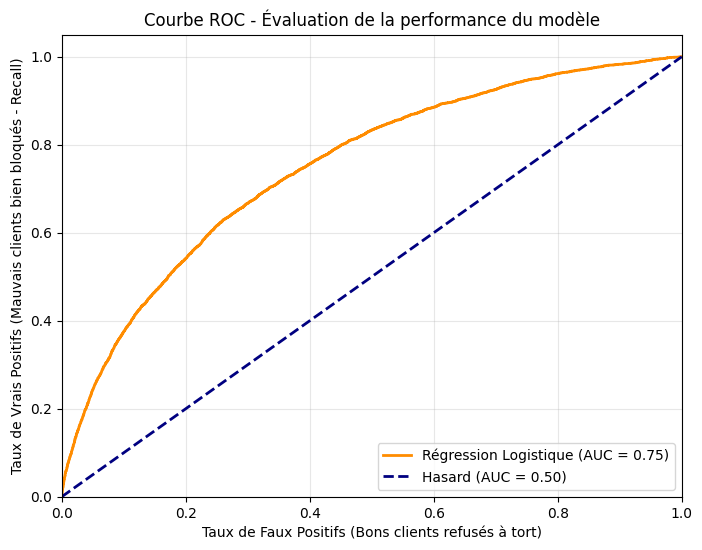

In [7]:
# 1. On récupère les probabilités prédites pour la classe 1 (les défauts)
# La fonction renvoie 2 colonnes (proba de 0, proba de 1). On sélectionne la 2ème avec [:, 1]
y_prob = modele_lr.predict_proba(X_test_scaled)[:, 1]

# 2. Calcul des points de la courbe et de l'AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
score_auc = auc(fpr, tpr)

# 3. Tracé du graphique
plt.figure(figsize=(8, 6))

# La courbe de notre modèle
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Régression Logistique (AUC = {score_auc:.2f})')

# La ligne diagonale (le pire modèle possible, qui joue à pile ou face)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard (AUC = 0.50)')

# Décoration pour faire joli et pro
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (Bons clients refusés à tort)')
plt.ylabel('Taux de Vrais Positifs (Mauvais clients bien bloqués - Recall)')
plt.title('Courbe ROC - Évaluation de la performance du modèle')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.show()